Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_832/2116603207.py:319: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.ffill().bfill())


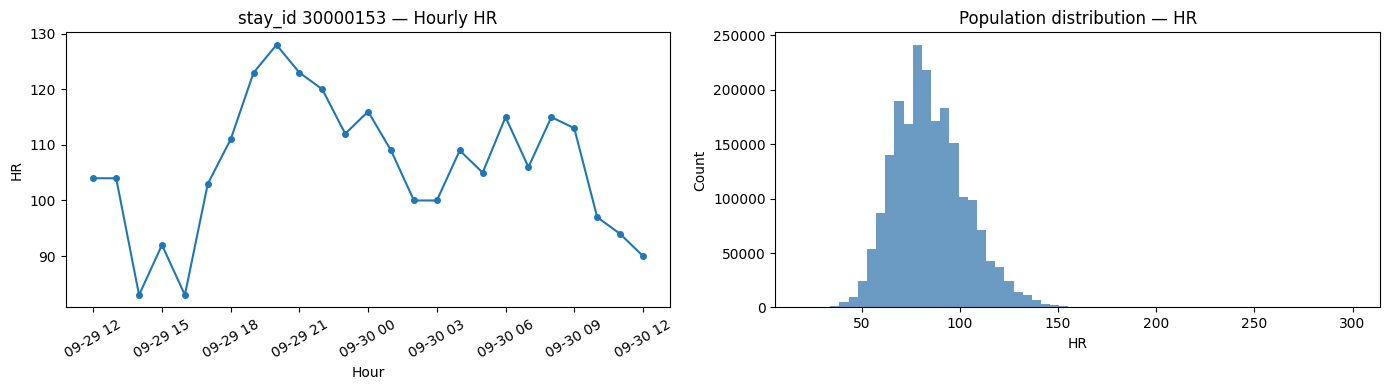

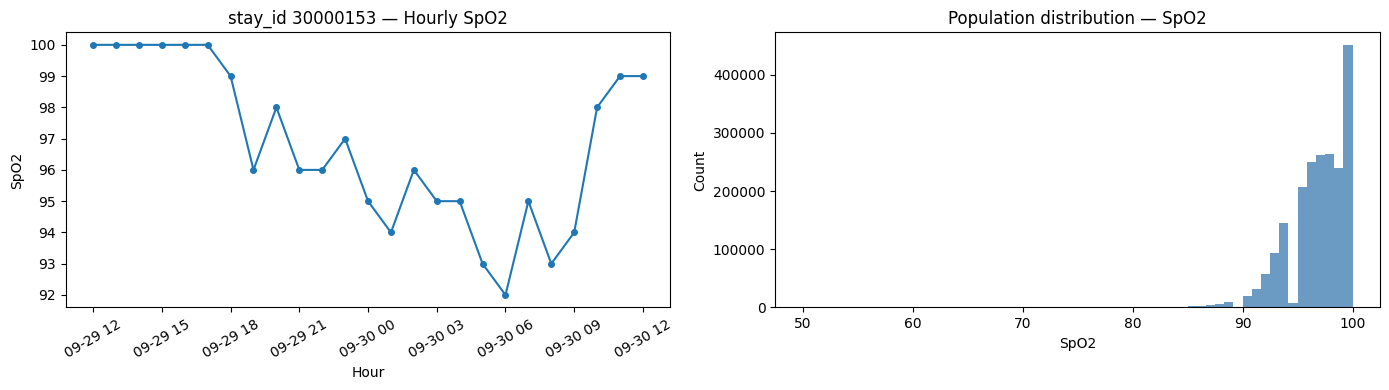

In [3]:
"""
ICUBaseFeatures_upgraded.py
============================
Industry-level rewrite of ICUBaseFeatures.ipynb
Changes vs original:
  - B1: Single merge (no intime_x / intime_y bug)
  - B2: Derived features (PF/SF ratio) computed BEFORE forward-fill
  - B3: One canonical ITEM_MAP reused for both chartevents and labevents
  - B4: Global random seed for reproducibility
  - B5: _missing indicator columns actually created before the binary_cols loop
  - U1: All paths and itemIDs in one CONFIG block at the top
  - U2: logging module instead of print()
  - U3: Each pipeline step wrapped in a named function
  - U4: Row-count assertions after every merge to catch silent join explosions
  - U5: Missing-value indicator columns added before imputation
  - U6: Physiological outlier clipping before aggregation
"""

# ─── STEP 0 — Imports & Config ──────────────────────────────────────────────

import logging
import random
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

# ── Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
from google.colab import drive
drive.mount('/content/drive')

# ── Paths  (only place you ever need to change them)
BASE    = Path("/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Dataset/mimic_iv/mimic-iv-3.1")
OUT_BASE = Path("/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet")
OUT_BASE.mkdir(parents=True, exist_ok=True)

HOURLY_FEATURES_PATH = OUT_BASE / "icu_hourly_features_24h.parquet"

# ── Item ID dictionaries  (single source of truth)
VITAL_ITEMS = {
    "HR":   [220045],
    "RR":   [220210],
    "SBP":  [220179, 220050],
    "DBP":  [220180, 220051],
    "MAP":  [220052, 220181],
    "TEMP": [223761, 223762],
    "SpO2": [220277],
}

LAB_ITEMS = {
    "Sodium":     [50983],
    "Potassium":  [50971],
    "Creatinine": [50912],
    "WBC":        [51301],
    "Hematocrit": [51221],
    "Platelets":  [51265],
    "Bilirubin":  [50885],
    "pH":         [50820],
    "PaO2":       [50821],
}

FIO2_IDS  = [223835, 3420, 190]
VENT_IDS  = [720, 223848, 223849, 467, 468, 469]
GCS_ITEMIDS = [
    223900,   # GCS - Verbal
    223901,   # GCS - Motor
    223902,   # GCS - Eye
]

# ── Build ONE canonical ITEM_MAP (fixes B3 — dual map divergence)
ITEM_MAP: dict[int, str] = {}
for feature_name, iid_list in {**VITAL_ITEMS, **LAB_ITEMS}.items():
    for iid in iid_list:
        ITEM_MAP[iid] = feature_name
for iid in FIO2_IDS:    ITEM_MAP[iid] = "FiO2"
for iid in VENT_IDS:    ITEM_MAP[iid] = "vent"
for iid in GCS_ITEMIDS: ITEM_MAP[iid] = "GCS"

ALL_ITEMIDS = set(ITEM_MAP.keys())

# ── Physiological valid ranges for outlier clipping (U6)
CLINICAL_RANGES: dict[str, tuple[float, float]] = {
    "HR":         (20,  300),
    "RR":         (4,   60),
    "SBP":        (50,  260),
    "DBP":        (20,  180),
    "MAP":        (30,  200),
    "TEMP":       (25,  45),
    "SpO2":       (50,  100),
    "GCS":        (3,   15),
    "Sodium":     (100, 180),
    "Potassium":  (1.5, 10),
    "Creatinine": (0.1, 30),
    "WBC":        (0,   200),
    "Hematocrit": (5,   70),
    "Platelets":  (5,   2000),
    "Bilirubin":  (0,   80),
    "pH":         (6.5, 8.0),
    "PaO2":       (20,  700),
    "FiO2":       (0.21, 1.0),
}

# ── Logging setup (U2 — replaces all print() calls)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)


# ─── STEP 1 — Mount Google Drive (Colab only) ────────────────────────────────

def mount_drive() -> None:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        log.info("Google Drive mounted.")
    except ImportError:
        log.info("Not running in Colab — skipping drive mount.")


# ─── STEP 2 — Load ICU Stay Map ──────────────────────────────────────────────

def load_icu_map() -> pd.DataFrame:
    """Load icustays.csv.gz and return the essential stay-level lookup table."""
    icu_map = pd.read_csv(
        BASE / "icu/icustays.csv.gz",
        usecols=["stay_id", "hadm_id", "subject_id", "intime", "outtime"],
    )
    icu_map["intime"]  = pd.to_datetime(icu_map["intime"])
    icu_map["outtime"] = pd.to_datetime(icu_map["outtime"])

    log.info("ICU stays loaded: %d rows", len(icu_map))
    assert icu_map["stay_id"].nunique() == len(icu_map), \
        "stay_id is not unique in icu_map — investigate before continuing."
    return icu_map


# ─── STEP 3 — Load & Filter Chartevents (ICU vitals/GCS) ────────────────────

def load_chartevents(icu_map: pd.DataFrame) -> pd.DataFrame:
    """
    Chunked read of chartevents.csv.gz.
    Keeps only rows matching ALL_ITEMIDS, then restricts to the
    first 24 hours of each ICU stay (single merge — fixes B1).
    """
    chunks = []
    for chunk in pd.read_csv(
        BASE / "icu/chartevents.csv.gz",
        usecols=["stay_id", "itemid", "charttime", "valuenum"],
        chunksize=2_000_000,
    ):
        chunk = chunk[chunk["itemid"].isin(ALL_ITEMIDS)].copy()
        if chunk.empty:
            continue
        chunk["charttime"] = pd.to_datetime(chunk["charttime"])
        chunks.append(chunk)

    icu_events = pd.concat(chunks, ignore_index=True)
    log.info("Chartevents rows after itemid filter: %d", len(icu_events))

    # ── Single merge (fixes B1 — no duplicate intime columns)
    pre_merge = len(icu_events)
    icu_events = icu_events.merge(
        icu_map[["stay_id", "intime"]], on="stay_id", how="inner"
    )
    assert len(icu_events) <= pre_merge * 1.05, \
        f"Row count grew suspiciously after merge: {pre_merge} → {len(icu_events)}"

    # ── Restrict to first 24 h
    icu_events = icu_events[
        (icu_events["charttime"] >= icu_events["intime"]) &
        (icu_events["charttime"] <= icu_events["intime"] + pd.Timedelta(hours=24))
    ]
    log.info("Chartevents rows after 24-h filter: %d", len(icu_events))

    icu_events["hour_ts"] = icu_events["charttime"].dt.floor("h")
    icu_events["variable"] = icu_events["itemid"].map(ITEM_MAP)  # uses single ITEM_MAP (fixes B3)
    return icu_events


# ─── STEP 4 — Load & Filter Labevents ───────────────────────────────────────

def load_labevents(icu_map: pd.DataFrame) -> pd.DataFrame:
    """
    Chunked read of labevents.csv.gz.
    Merges on hadm_id → stay_id, restricts to first 24 h of ICU stay.
    Uses the shared ITEM_MAP (fixes B3).
    """
    lab_itemids = {iid for ids in LAB_ITEMS.values() for iid in ids}
    lab_chunks = []

    for chunk in pd.read_csv(
        BASE / "hosp/labevents.csv.gz",
        usecols=["hadm_id", "itemid", "charttime", "valuenum"],
        chunksize=1_000_000,
    ):
        chunk = chunk[chunk["itemid"].isin(lab_itemids)].copy()
        if chunk.empty:
            continue
        chunk["charttime"] = pd.to_datetime(chunk["charttime"])
        lab_chunks.append(chunk)

    labevents = pd.concat(lab_chunks, ignore_index=True)
    log.info("Labevents rows after itemid filter: %d", len(labevents))

    pre_merge = len(labevents)
    labevents = labevents.merge(
        icu_map[["hadm_id", "stay_id", "intime"]], on="hadm_id", how="inner"
    )
    assert len(labevents) <= pre_merge * 2, \
        f"Labevents exploded after merge: {pre_merge} → {len(labevents)}"

    labevents = labevents[
        (labevents["charttime"] >= labevents["intime"]) &
        (labevents["charttime"] <= labevents["intime"] + pd.Timedelta(hours=24))
    ]
    log.info("Labevents rows after 24-h filter: %d", len(labevents))

    labevents["hour_ts"] = labevents["charttime"].dt.floor("h")
    labevents["variable"] = labevents["itemid"].map(ITEM_MAP)  # fixes B3
    return labevents


# ─── STEP 5 — Clip Outliers Before Aggregation ──────────────────────────────

def clip_outliers(events: pd.DataFrame) -> pd.DataFrame:
    """
    Apply physiological valid ranges (U6).
    Done on the RAW event rows BEFORE hourly aggregation so that a single
    erroneous measurement doesn't corrupt the mean.
    """
    for variable, (lo, hi) in CLINICAL_RANGES.items():
        mask = events["variable"] == variable
        events.loc[mask, "valuenum"] = events.loc[mask, "valuenum"].clip(lo, hi)
    log.info("Outlier clipping applied.")
    return events


# ─── STEP 6 — Hourly Aggregation ─────────────────────────────────────────────

def aggregate_hourly(events: pd.DataFrame) -> pd.DataFrame:
    """Pivot to (stay_id, hour_ts) × variable with mean aggregation."""
    hourly = (
        events
        .groupby(["stay_id", "hour_ts", "variable"])["valuenum"]
        .mean()
        .unstack("variable")
        .reset_index()
    )
    log.info("Hourly feature shape after aggregation: %s", hourly.shape)
    return hourly


# ─── STEP 7 — Merge Chartevents + Labevents Hourly Features ─────────────────

def merge_hourly(chart_hourly: pd.DataFrame, labs_hourly: pd.DataFrame) -> pd.DataFrame:
    """
    Left-join lab hourly features into the chart hourly table on (stay_id, hour_ts).
    Resolves duplicate column names from the two separate unstack() calls.
    """
    # Rename lab columns that already exist in chart_hourly to avoid _x/_y suffixes
    lab_only_cols = [
        c for c in labs_hourly.columns
        if c not in {"stay_id", "hour_ts"} and c not in chart_hourly.columns
    ]
    merged = chart_hourly.merge(
        labs_hourly[["stay_id", "hour_ts"] + lab_only_cols],
        on=["stay_id", "hour_ts"],
        how="left",
    )
    log.info("After merging labs into chart features: %s", merged.shape)
    return merged


# ─── STEP 8 — Feature Engineering ────────────────────────────────────────────

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Order: clip → missingness flags → derived ratios → impute.
    Fixes B2 (ratios before ffill) and B5 (_missing cols now created here).
    """
    # ── FiO2 normalisation (percentage → fraction)
    if "FiO2" in df.columns:
        df["FiO2"] = np.where(df["FiO2"] > 1, df["FiO2"] / 100, df["FiO2"])
        df["FiO2"] = df["FiO2"].fillna(0.21)   # room-air default

    # ── Ventilation binary flag
    if "vent" in df.columns:
        df["vent"] = df["vent"].notna().astype(int)

    # ── U5: Create _missing indicator columns BEFORE any imputation
    clinical_cols = [
        c for c in df.columns
        if c not in {"stay_id", "hour_ts", "vent"}
    ]
    for col in clinical_cols:
        df[f"{col}_missing"] = df[col].isna().astype(int)

    # ── B2 fix: Compute derived ratios NOW (before ffill, using raw measured values)
    if "PaO2" in df.columns and "FiO2" in df.columns:
        df["PF_ratio"] = df["PaO2"] / df["FiO2"]

    if "SpO2" in df.columns and "FiO2" in df.columns:
        df["SF_ratio"] = df["SpO2"] / df["FiO2"]

    # ── Forward-fill then backward-fill within each stay (after ratios)
    df = (
        df
        .sort_values(["stay_id", "hour_ts"])
        .groupby("stay_id", group_keys=False)
        .apply(lambda g: g.ffill().bfill())
        .reset_index(drop=True)
    )

    log.info("Feature engineering complete. Shape: %s", df.shape)
    return df


# ─── STEP 9 — Dtype Optimisation ─────────────────────────────────────────────

def optimise_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """Cast float64 → float32 to halve memory, int-ify binary columns (B5 fix)."""
    # B5 fix: _missing columns now actually exist, so this loop does real work
    binary_cols = [c for c in df.columns if c.endswith("_missing") or c == "vent"]
    for col in binary_cols:
        df[col] = df[col].astype("int8")

    float_cols = df.select_dtypes(include=["float64"]).columns
    df[float_cols] = df[float_cols].astype("float32")

    log.info("Dtypes optimised. Memory: %.1f MB", df.memory_usage(deep=True).sum() / 1e6)
    return df


# ─── STEP 10 — Validation ────────────────────────────────────────────────────

def validate(df: pd.DataFrame) -> None:
    """Sanity checks before saving (U4 — post-pipeline assertions)."""
    assert "stay_id" in df.columns,  "stay_id column missing"
    assert "hour_ts" in df.columns,  "hour_ts column missing"
    assert df["stay_id"].notna().all(), "NaN stay_ids found"

    top_nan = df.isna().sum().sort_values(ascending=False).head(10)
    log.info("Top remaining NaN counts:\n%s", top_nan.to_string())

    n_stays  = df["stay_id"].nunique()
    n_rows   = len(df)
    avg_hrs  = n_rows / n_stays
    log.info("Stays: %d | Rows: %d | Avg hours/stay: %.1f", n_stays, n_rows, avg_hrs)
    assert avg_hrs <= 25, f"Average hours/stay is {avg_hrs:.1f} — expected ≤25 for 24-h window"


# ─── STEP 11 — Save ──────────────────────────────────────────────────────────

def save(df: pd.DataFrame) -> None:
    df.sort_values(["stay_id", "hour_ts"]).to_parquet(HOURLY_FEATURES_PATH, index=False)
    log.info("Saved: %s", HOURLY_FEATURES_PATH)


# ─── STEP 12 — Sanity Plot ────────────────────────────────────────────────────

def sanity_plot(df: pd.DataFrame, variable: str = "HR") -> None:
    """Plot one patient's hourly trend for a quick visual check."""
    sid = df["stay_id"].iloc[0]
    pt  = df[df["stay_id"] == sid]

    if variable not in pt.columns:
        log.warning("Variable '%s' not in features — skipping plot.", variable)
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Trend
    axes[0].plot(pt["hour_ts"], pt[variable], marker="o", ms=4, lw=1.5)
    axes[0].set_title(f"stay_id {sid} — Hourly {variable}")
    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel(variable)
    axes[0].tick_params(axis="x", rotation=30)

    # Population distribution
    axes[1].hist(df[variable].dropna(), bins=60, edgecolor="none", color="steelblue", alpha=0.8)
    axes[1].set_title(f"Population distribution — {variable}")
    axes[1].set_xlabel(variable)
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.savefig(OUT_BASE / f"sanity_{variable}.png", dpi=120, bbox_inches="tight")
    plt.show()
    log.info("Sanity plot saved.")


# ─── MAIN PIPELINE ────────────────────────────────────────────────────────────

def main() -> None:
    mount_drive()

    log.info("=== STEP 1/9  Loading ICU map ===")
    icu_map = load_icu_map()

    log.info("=== STEP 2/9  Loading chartevents ===")
    icu_events = load_chartevents(icu_map)

    log.info("=== STEP 3/9  Loading labevents ===")
    labevents = load_labevents(icu_map)

    log.info("=== STEP 4/9  Clipping outliers ===")
    icu_events = clip_outliers(icu_events)
    labevents  = clip_outliers(labevents)

    log.info("=== STEP 5/9  Hourly aggregation ===")
    chart_hourly = aggregate_hourly(icu_events)
    labs_hourly  = aggregate_hourly(labevents)

    log.info("=== STEP 6/9  Merging chart + lab features ===")
    hourly_features = merge_hourly(chart_hourly, labs_hourly)

    log.info("=== STEP 7/9  Feature engineering ===")
    hourly_features = engineer_features(hourly_features)

    log.info("=== STEP 8/9  Optimising dtypes ===")
    hourly_features = optimise_dtypes(hourly_features)

    log.info("=== STEP 9/9  Validation + save ===")
    validate(hourly_features)
    save(hourly_features)

    sanity_plot(hourly_features, "HR")
    sanity_plot(hourly_features, "SpO2")

    log.info("Pipeline complete.")


if __name__ == "__main__":
    main()

In [2]:
# ── Paste and run this FIRST ─────────────────────────────
import os

# Check 1: Is the DataFrame still in memory?
df_alive = "hourly_features" in dir()
print("DataFrame in memory:", df_alive)

# Check 2: Did the file get written at all?
file_exists = HOURLY_FEATURES_PATH.exists()
print("Parquet file exists:", file_exists)

# Check 3: Is Drive still mounted?
drive_ok = os.path.exists("/content/drive/MyDrive")
print("Drive mounted:", drive_ok)

DataFrame in memory: False
Parquet file exists: True
Drive mounted: True
